An insurance company wants to develop a better understanding of its claims paid out for medical malpractice lawsuits and pulled some data from its information system for analysis.  The data is contained in the file **medicalMalpractice.csv**  on the course the Canvas site under the Datafiles module.  We want to gather insights regarding medical practice claims according to the data provided.

First, we load the necessary packages, read the data file, and print out the top of the data frame to check it out:

In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
import scipy.stats as stats
import statsmodels.api as sm

#bring the file Medical Malpractice into a python dataframe
df = pd.read_csv('data/medicalMalpractice.csv')
# convert any non numeric numbers to NaN so that the calculations and boxplots can work
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
print(df.head())

   Amount  Severity  Age  Private Attorney  Marital Status  \
0  426500         6   37                 1               2   
1   64000         4   66                 1               2   
2   17604         7   69                 1               2   
3    1986         3   56                 0               2   
4   41500         5   42                 1               2   

            Specialty  Insurance  Gender        Unnamed: 8  \
0          Pediatrics          1  Female    Marital Status   
1     Plastic Surgeon          2  Female         Insurance   
2   Internal Medicine          1    Male  Private Attorney   
3  Urological Surgery          1  Female          Severity   
4     General Surgery          4    Male            Gender   

                                          Unnamed: 9  
0  0=divorced, 1=single, 2=married, 3=widowed, 4=...  
1  1=private, 2=Medicare/Medicaid, 3=No insurance...  
2  Claimant represented by private attorney: 1=Pr...  
3                  1 (emotional tr

Looks like the last two columns provide the data dictionary, so we drop them:

In [2]:
# Drop the last two columns
df = df.drop(df.columns[-2:], axis=1)
print(df.head())

   Amount  Severity  Age  Private Attorney  Marital Status  \
0  426500         6   37                 1               2   
1   64000         4   66                 1               2   
2   17604         7   69                 1               2   
3    1986         3   56                 0               2   
4   41500         5   42                 1               2   

            Specialty  Insurance  Gender  
0          Pediatrics          1  Female  
1     Plastic Surgeon          2  Female  
2   Internal Medicine          1    Male  
3  Urological Surgery          1  Female  
4     General Surgery          4    Male  


Next, we choose the variable ***Amount*** and run the basic descriptive numerical analysis for that variable – observations count, mean, standard deviation, median, interquartile range, minimum, maximum. We then examine the distribution of claim amount using a histogram and a box plot

  variable    N      mean   std dev   Median      IQR   Min     Max
0   Amount  118  91044.92  164501.8  22750.0  82625.0  1550  926500


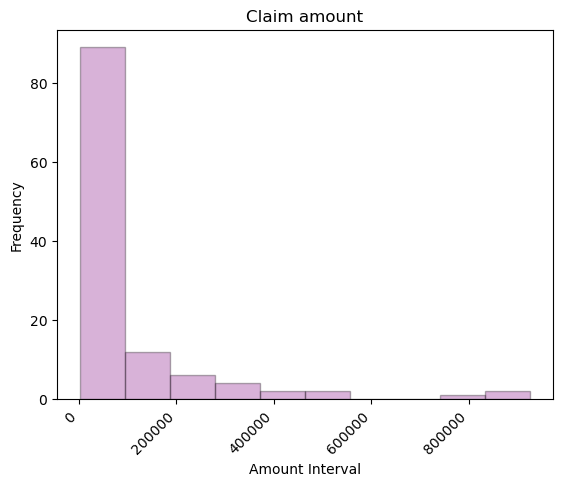

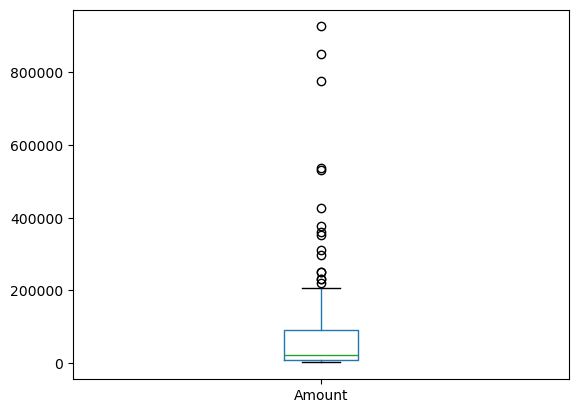

In [3]:
q75, q25 = np.percentile(df['Amount'], [75 ,25])
iqr = q75 - q25
iqr_rounded = float("{:.2f}".format(iqr))

#create a variable for standard deviation so we can round to 2 decimal places for a cleaner look
stdev=df['Amount'].std(ddof = 1) #we use sample standard deviation formula
stdev_rounded = float("{:.2f}".format(stdev))

#create a variable for median so we can round to 2 decimal places for a cleaner look
med=df['Amount'].median()
median_rounded = float("{:.2f}".format(med))


# get descriptive statistics for HseCost column
Descriptive_Stats = {
    'variable': ['Amount'],
     'N': df['Amount'].count(),   
     'mean': df['Amount'].mean().round(2),      
     'std dev': stdev_rounded,        
     'Median': median_rounded,
    'IQR' : iqr_rounded,
    'Min' : df['Amount'].min(axis=0),
    'Max' : df['Amount'].max(axis=0),
    }

df_output=pd.DataFrame(Descriptive_Stats)
print(df_output)
#create the histogram for the variable Amount
plt.hist(df['Amount'],edgecolor='black', color = "purple", alpha = 0.3)

#label the histogram appropriately
plt.xlabel('Amount Interval')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Frequency')
plt.title('Claim amount')
plt.show()


#create boxplot of HseCost
boxplot=df.boxplot(column = 'Amount')
boxplot.grid(False)
plt.show()


Think: shat does this information indicate about the variable ***Amount***?

Next, we run descriptive analysis for the remaining variables.  Think: what variables are qualitative and what variables are quantitative? We need to choose the appropriate tables, graphs, and numerical measures based on the variable measurement.

Exercise on your own: perform the same descriptive statistical analysis for the variable ***Age***

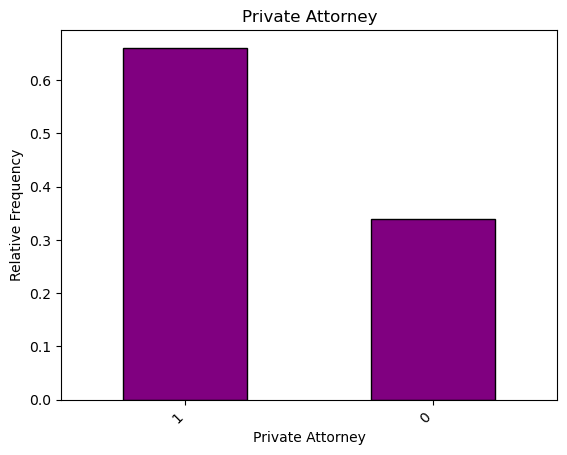

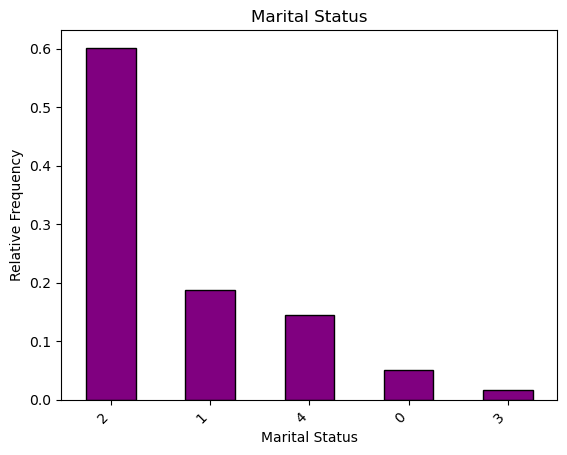

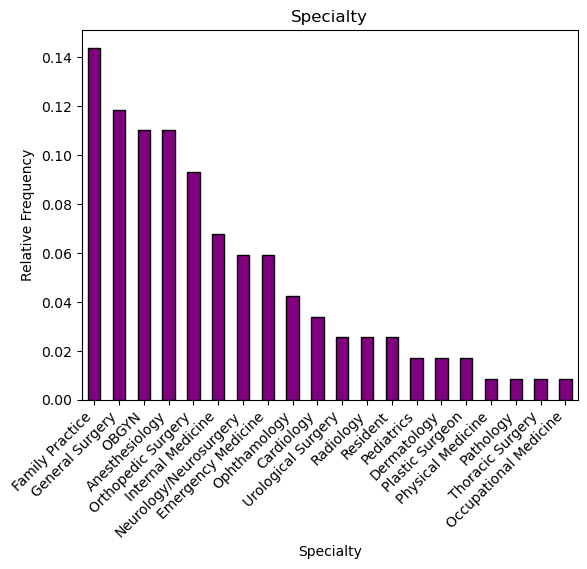

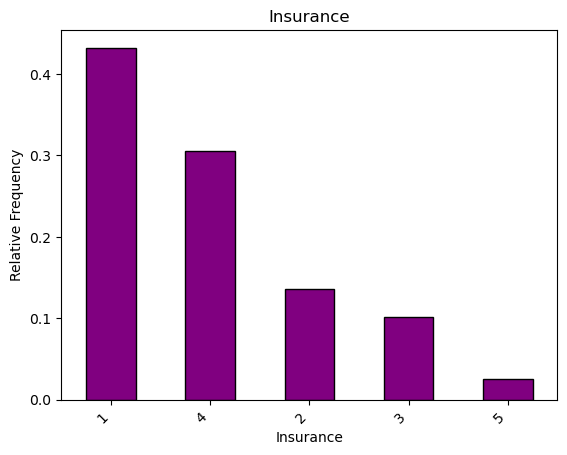

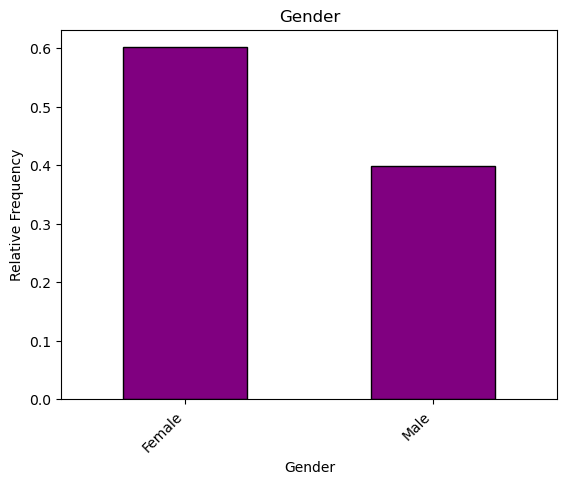

In [4]:
# List of qualitative variables
qualitative_vars = ['Private Attorney', 'Marital Status', 'Specialty', 'Insurance', 'Gender']

# Loop through each qualitative variable and create relative frequency charts
for var in qualitative_vars:
    # Calculate relative frequencies
    relative_freq = df[var].value_counts(normalize=True)
    
    # Plot the relative frequency chart
    relative_freq.plot(kind='bar', color='purple', edgecolor='black')
    plt.title(f'{var}')
    plt.xlabel(var)
    plt.ylabel('Relative Frequency')
    plt.xticks(rotation=45, ha='right')
    plt.show()

Let's examine relationships between quantitative and qualitative variables. Example: Amount and Private attorney.  It could be that those who use a private attorney (independent variable) would have higher payout amounts (dependent variable) because without an attorney a customer may not have insight on the ways to get the claim approved. Let us check this.

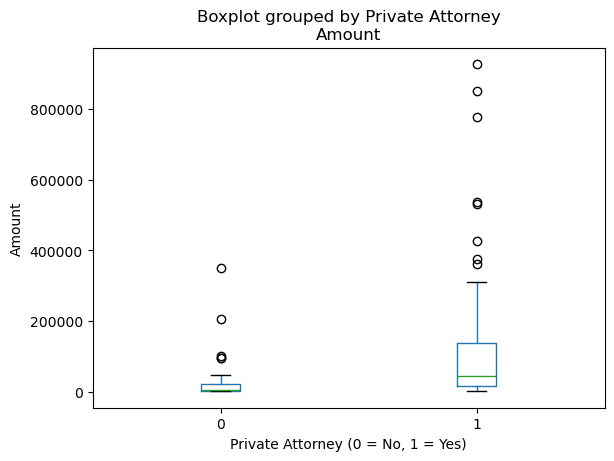

In [5]:
#create side by side boxplot of Amount by Private Attorney
boxplot=df.boxplot(column = 'Amount', by='Private Attorney')
boxplot.grid(False)
plt.ylabel("Amount")
plt.xlabel('Private Attorney (0 = No, 1 = Yes)')
plt.show()

On your own: use a box plot to examine the relationship between the variables ***Specialty*** and ***Amount***

An example of examining relationship between two qualitative variables using cross tabulation:


Crosstab Table
        No  Yes
Gender         
Female  24   47
Male    16   31

Crosstab Table with Percentages:
               No        Yes
Gender                      
Female  33.802817  66.197183
Male    34.042553  65.957447


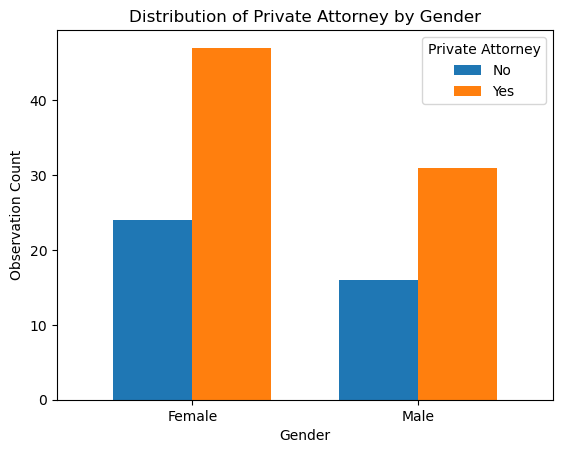

In [6]:

# Create the crosstab with percentages
crosstab_gender = pd.crosstab(df['Gender'], df['Private Attorney'])
# Update the column names to display 'Yes' and 'No' instead of 1 and 0
crosstab_gender.columns = ['No', 'Yes']


print("\nCrosstab Table")
print(crosstab_gender)


# Create the crosstab with percentages
crosstab_percent = pd.crosstab(df['Gender'], df['Private Attorney'], normalize='index') * 100
# Update the column names to display 'Yes' and 'No' instead of 1 and 0
crosstab_percent.columns = ['No', 'Yes']

print("\nCrosstab Table with Percentages:")
print(crosstab_percent)

# Create the bar plot for percentages
barplot = crosstab_gender.plot.bar(rot=0, width=0.7)

# Customize the barplot
barplot.set_title('Distribution of Private Attorney by Gender')
barplot.set_xlabel("Gender")
barplot.set_ylabel("Observation Count")
barplot.legend(title='Private Attorney')


# Show the plot
plt.show()

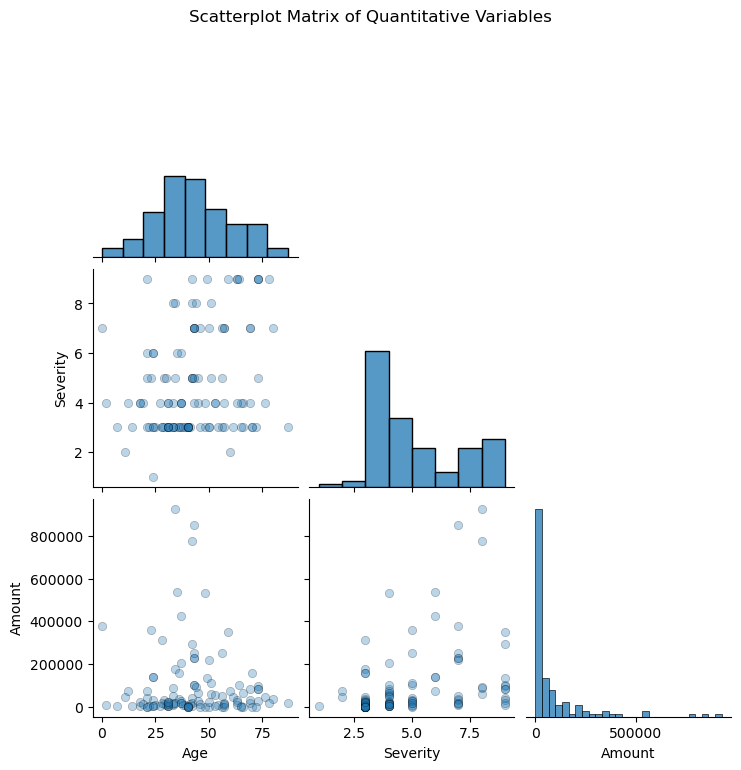

In [13]:
sns.pairplot(df[[ 'Age', 'Severity',  'Amount']], kind='scatter', diag_kind='hist', corner=True, plot_kws={'alpha': 0.3, 'edgecolor': 'black'})

# Add a title to the scatterplot matrix
plt.suptitle('Scatterplot Matrix of Quantitative Variables', y=1.02)
plt.show()
                                                                                                    

# Regression Analysis

## Simple Linear Regression: Severity by Age
First, a simple linear regression exploring the relationship between age and severity:

In [7]:

# Define independent and dependent variables
age = df[['Age']]
age = sm.add_constant(age)  # Add intercept
severity = df['Severity']

# Fit the OLS model
modelSeverity = sm.OLS(severity, age).fit()

# Print the regression summary
print(modelSeverity.summary())

                            OLS Regression Results                            
Dep. Variable:               Severity   R-squared:                       0.075
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     9.473
Date:                Mon, 02 Dec 2024   Prob (F-statistic):            0.00260
Time:                        20:05:34   Log-Likelihood:                -248.67
No. Observations:                 118   AIC:                             501.3
Df Residuals:                     116   BIC:                             506.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.3613      0.479      7.022      0.0

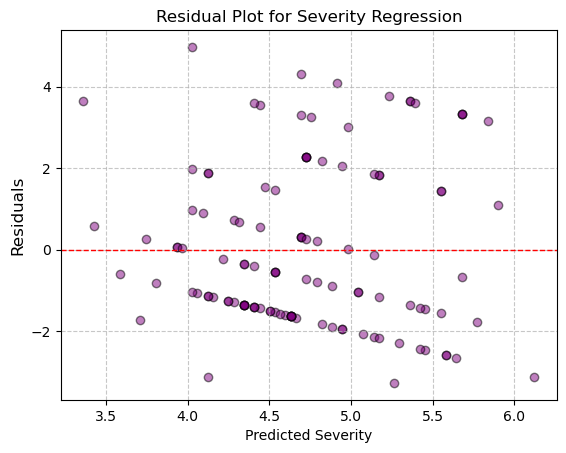

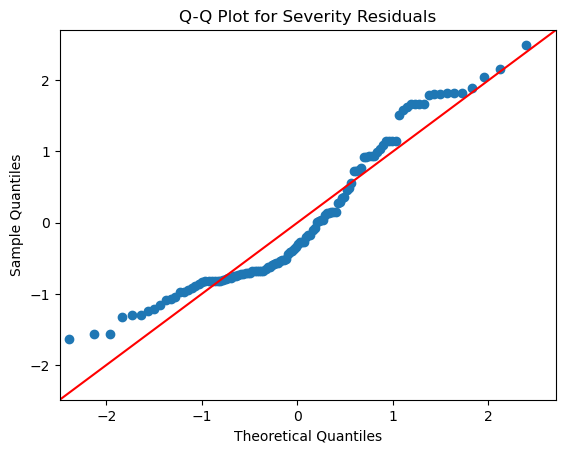

In [23]:
# Residuals
residualsSeverity = modelSeverity.resid

# Predicted values
predictedSeverity = modelSeverity.fittedvalues


# Residual Plot
plt.scatter(predictedSeverity, residualsSeverity, color='purple', alpha=0.5, edgecolor='black')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.title('Residual Plot for Severity Regression')
plt.xlabel('Predicted Severity')
plt.ylabel('Residuals', fontsize=12)
plt.grid(alpha=0.7, linestyle='--')
plt.show()

# Q-Q Plot
sm.qqplot(residualsSeverity, line='45', fit=True)
plt.title('Q-Q Plot for Severity Residuals')
plt.show()

Creating a Confidence Interval for Regression line

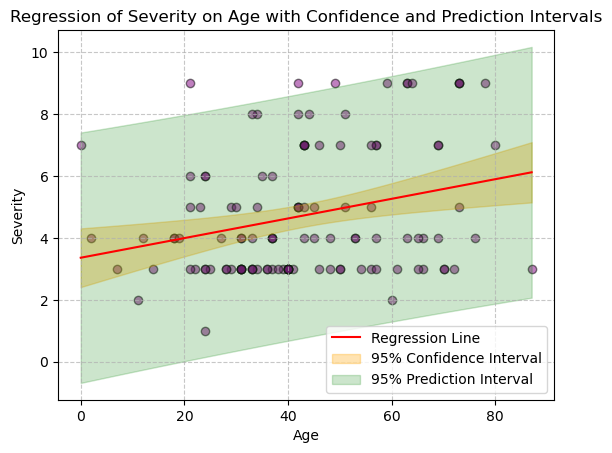

In [42]:
# Scatterplot with prediction confidence interval
# Generate new Age values for predictions
age_range = np.linspace(df['Age'].min(), df['Age'].max(), 100)
X_new = sm.add_constant(age_range)  # Add intercept to new data
predictionsSeverity = modelSeverity.get_prediction(X_new)

# Extract prediction and confidence intervals
predicted_mean = predictionsSeverity.predicted_mean
conf_int = predictionsSeverity.conf_int()

se_obs = predictionsSeverity.se_obs  # Standard error of observations
pred_int = np.column_stack([predicted_mean - 1.96 * se_obs, predicted_mean + 1.96 * se_obs])  # Prediction interval

# Plot scatterplot with confidence interval
plt.scatter(df['Age'], df['Severity'], color='purple', alpha=0.5, edgecolor='black')
plt.plot(age_range, predicted_mean, color='red', label='Regression Line')
plt.fill_between(age_range, conf_int[:, 0], conf_int[:, 1], color='orange', alpha=0.3, label='95% Confidence Interval')
plt.fill_between(age_range, pred_int[:, 0], pred_int[:, 1], color='green', alpha=0.2, label='95% Prediction Interval')
plt.title('Regression of Severity on Age with Confidence and Prediction Intervals')
plt.xlabel('Age')
plt.ylabel('Severity')
plt.legend()
plt.grid(alpha=0.7, linestyle='--')
plt.show()

## Multiple Regression for Amount

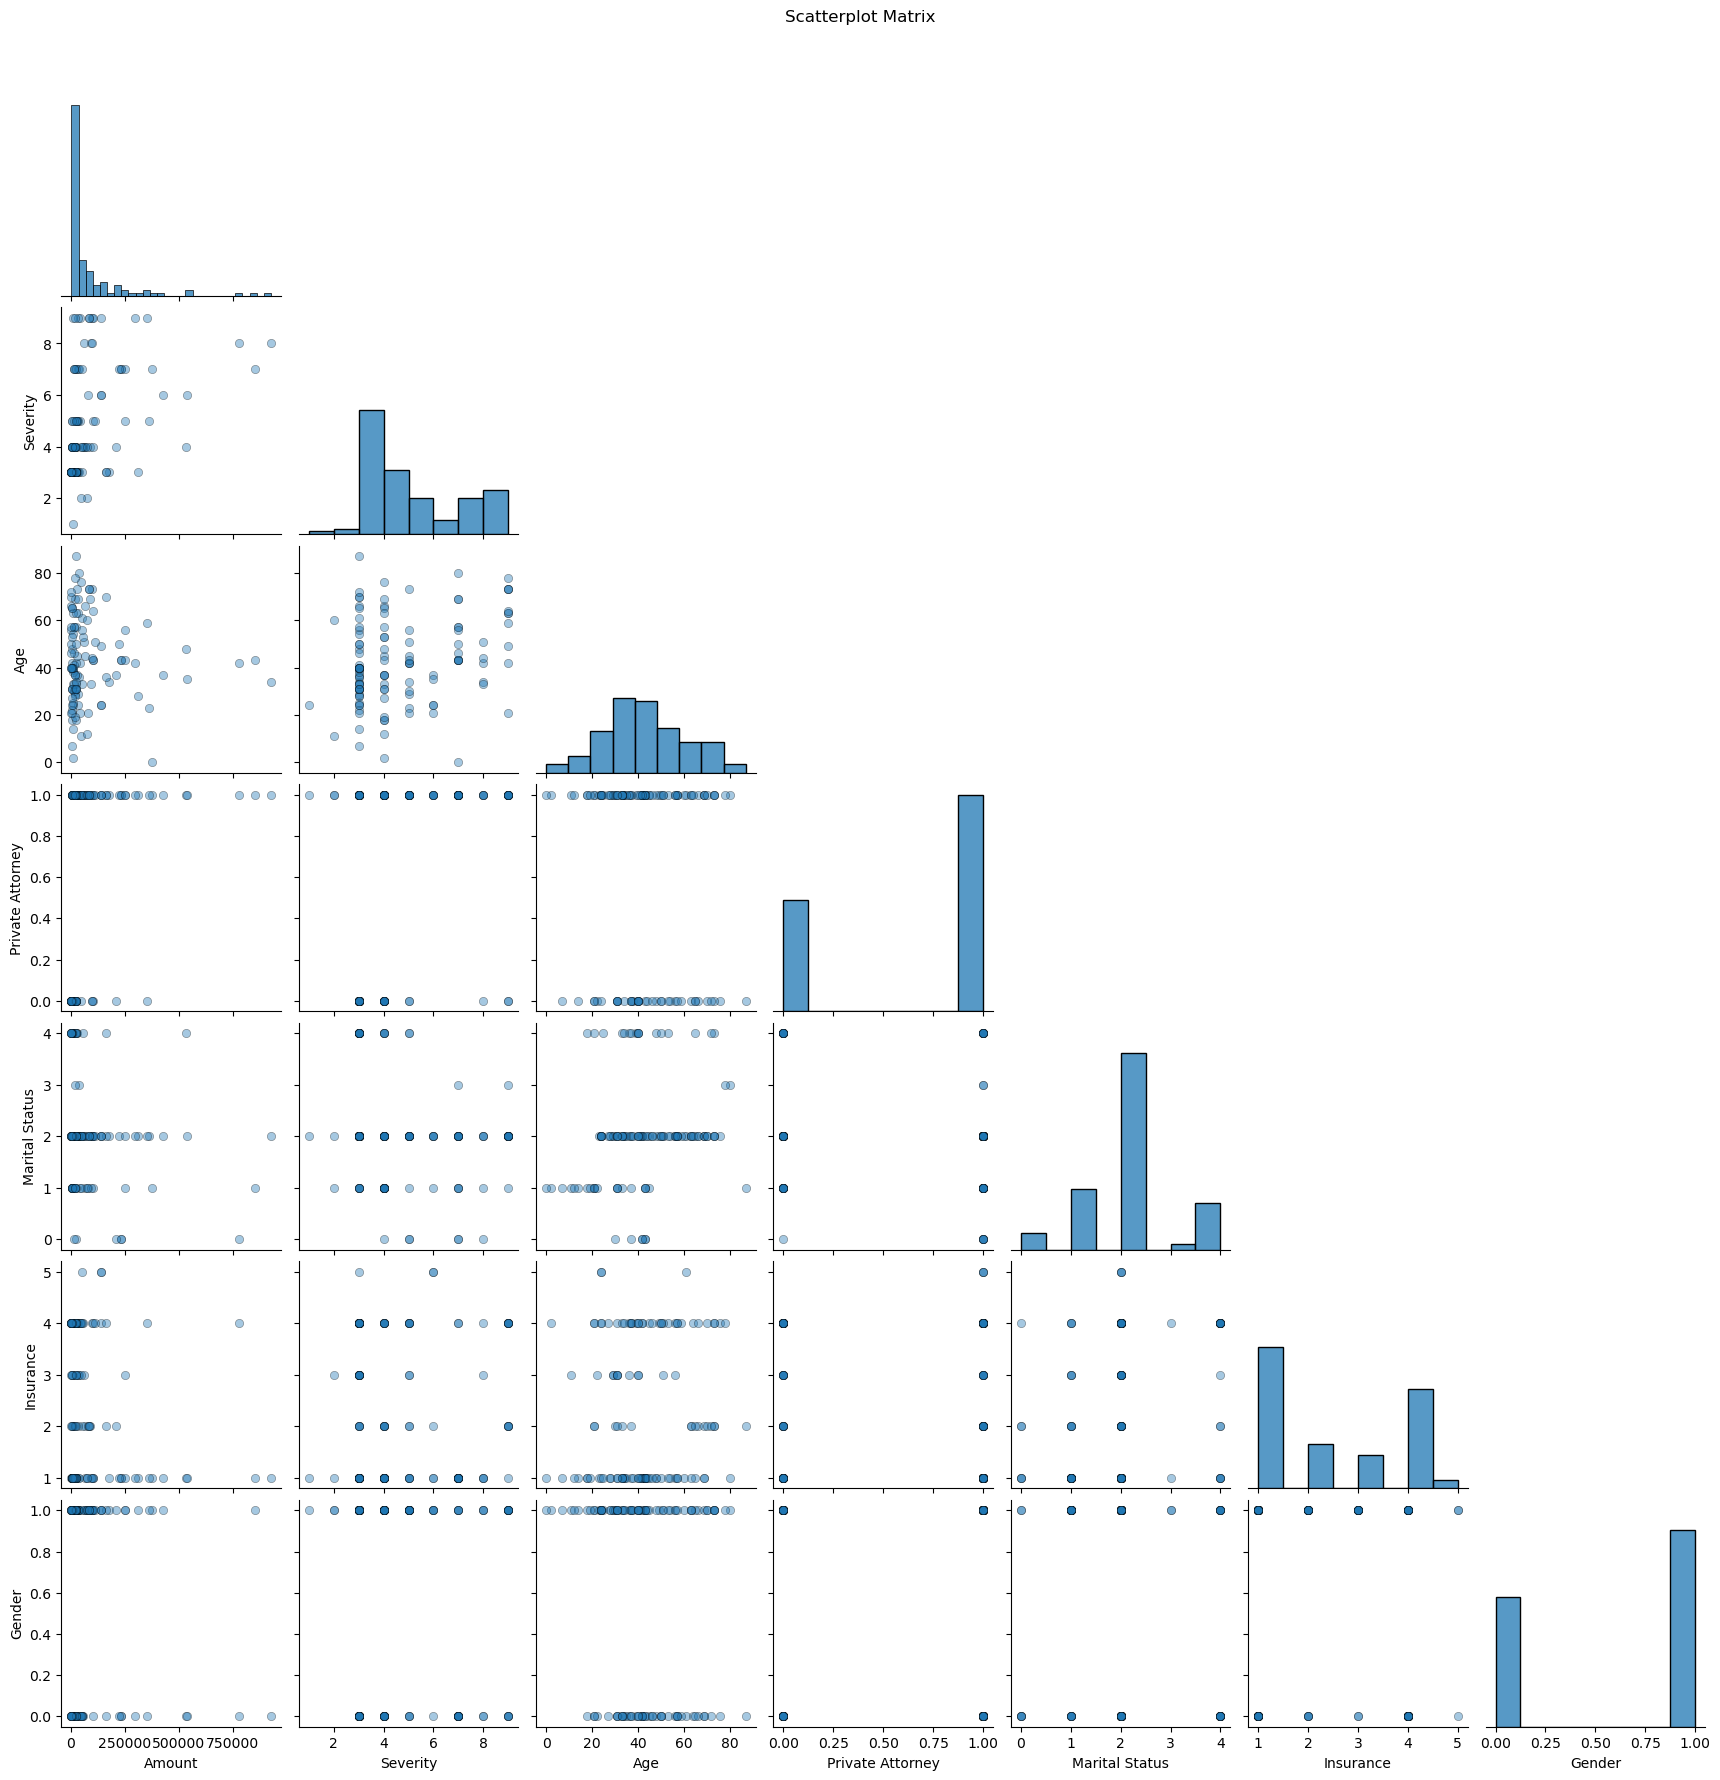

In [42]:
# Create scatterplot matrix for all  variables
sns.pairplot(df, kind='scatter', diag_kind='hist', corner=True,  plot_kws={'alpha': 0.4, 'edgecolor': 'black'})

# Add a title to the plot
plt.suptitle('Scatterplot Matrix', y=1.02)
plt.show()

Let us double-check the correlation matrix for potential collinearity problems:

In [8]:
# Convert Gender to binary: Female = 1, Male = 0
df['Gender'] = df['Gender'].map({'Female': 1, 'Male': 0})

# Drop the Marital Status and Insurance columna, as they are qualitative
df1 = df.drop(columns=['Marital Status', 'Insurance'])

# Ensure all variables are numeric
df1 = df1.select_dtypes(include='number')

# Calculate the correlation matrix
correlation_matrix = df1.corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
                    Amount  Severity       Age  Private Attorney    Gender
Amount            1.000000  0.386587 -0.058545          0.267967 -0.081562
Severity          0.386587  1.000000  0.274766          0.335637 -0.059735
Age              -0.058545  0.274766  1.000000         -0.099640 -0.138046
Private Attorney  0.267967  0.335637 -0.099640          1.000000  0.002479
Gender           -0.081562 -0.059735 -0.138046          0.002479  1.000000


In [9]:
# Define independent variables (exclude Insurance and Marital Status)
X = df[['Severity', 'Age', 'Private Attorney', 'Gender']]
X = sm.add_constant(X)  # Add intercept (constant) to the model
y = df['Amount']  # Dependent variable

# Fit the OLS model
model = sm.OLS(y, X).fit()

# Print summary of the regression
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                 Amount   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.170
Method:                 Least Squares   F-statistic:                     6.978
Date:                Mon, 02 Dec 2024   Prob (F-statistic):           4.67e-05
Time:                        20:38:22   Log-Likelihood:                -1571.2
No. Observations:                 118   AIC:                             3152.
Df Residuals:                     113   BIC:                             3166.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             -582.5097   5.04e+04  

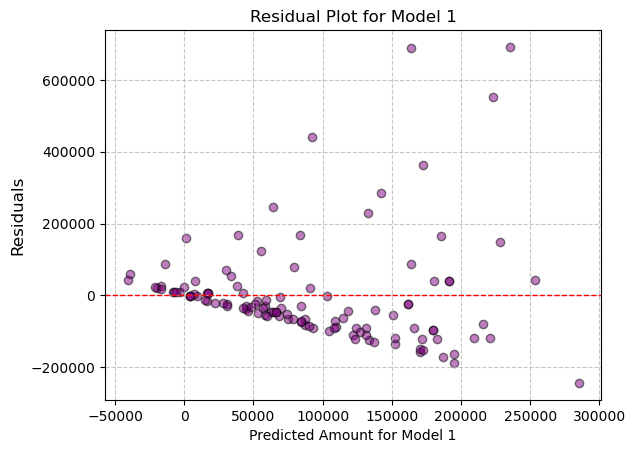

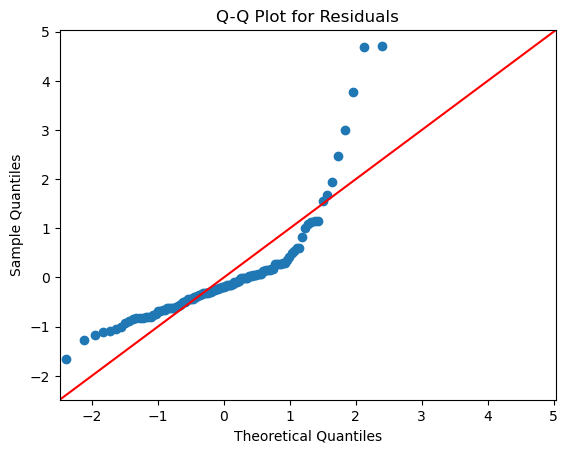

In [52]:
# Residuals
residuals = model.resid

# Predicted values
predicted = model.fittedvalues

# Residual Plot
plt.scatter(predicted, residuals, color='purple', alpha=0.5, edgecolor='black')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.title('Residual Plot for Model 1')
plt.xlabel('Predicted Amount for Model 1')
plt.ylabel('Residuals', fontsize=12)
plt.grid(alpha=0.7, linestyle='--')
plt.show()

# Q-Q Plot
sm.qqplot(residuals, line='45', fit=True)
plt.title('Q-Q Plot for Residuals')
plt.show()

In [10]:
# Fit the OLS model with robust standard errors
model2 = sm.OLS(y, X).fit(cov_type='HC3')  # Use HC3 for heteroscedasticity-robust standard errors

# Print summary of the regression with robust standard errors
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                 Amount   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.170
Method:                 Least Squares   F-statistic:                     4.712
Date:                Mon, 02 Dec 2024   Prob (F-statistic):            0.00149
Time:                        20:52:20   Log-Likelihood:                -1571.2
No. Observations:                 118   AIC:                             3152.
Df Residuals:                     113   BIC:                             3166.
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const             -582.5097   3.75e+04  

Better, we can try rescaling the dependent variable, taking a natural logarithm of it. This is a common approach when you see "fanning out" residual errors.

In [12]:
ylog = np.log(df['Amount'])  # Dependent variable is a logarithm of Amount
ylog.name = "log(Amount)"
# Fit the OLS model
model3 = sm.OLS(ylog, X).fit()

# Print summary of the regression
print(model3.summary())


                            OLS Regression Results                            
Dep. Variable:            log(Amount)   R-squared:                       0.397
Model:                            OLS   Adj. R-squared:                  0.375
Method:                 Least Squares   F-statistic:                     18.57
Date:                Mon, 02 Dec 2024   Prob (F-statistic):           9.39e-12
Time:                        20:53:31   Log-Likelihood:                -196.24
No. Observations:                 118   AIC:                             402.5
Df Residuals:                     113   BIC:                             416.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                7.9556      0.439  

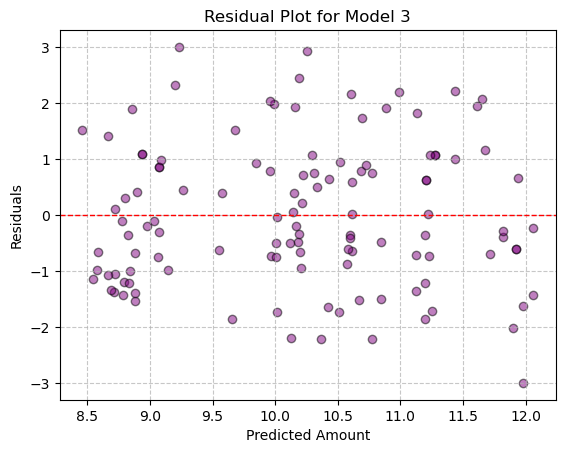

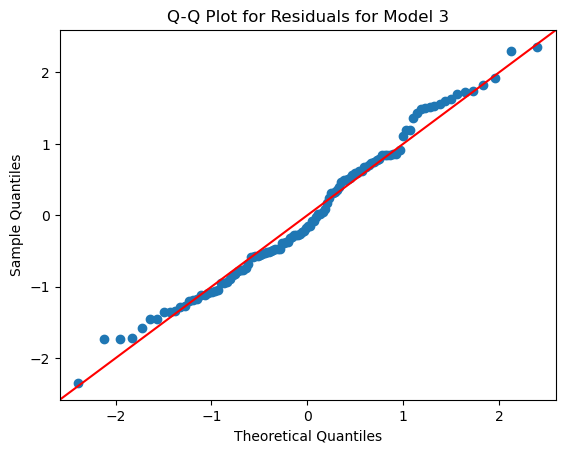

In [13]:
# Residuals
residuals = model3.resid

# Predicted values
predicted = model3.fittedvalues

# Residual Plot
plt.scatter(predicted, residuals, color='purple', alpha=0.5, edgecolor='black')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.title('Residual Plot for Model 3')
plt.xlabel('Predicted Amount')
plt.ylabel('Residuals')
plt.grid(alpha=0.7, linestyle='--')
plt.show()

# Q-Q Plot
sm.qqplot(residuals, line='45', fit=True)
plt.title('Q-Q Plot for Residuals for Model 3')
plt.show()